In [11]:
from pathlib import Path
import pandas as pdtimestamp 	source_file 	command 	message 	line_no
0 	2026-08-09 07:05:27 	ble_change.txt 	A7 	2026-08-09 07:05:27||695:-->watch::::::>device... 	2
1 	2026-08-09 07:05:27 	ble_change.txt 	A7 	2026-08-09 07:05:27||722:-->watch::::::>device... 	21
2 	2026-08-09 07:05:27 	ble_change.txt 	A7 	2026-08-09 07:05:27||740:-->watch::::::>device... 	40
3 	2026-08-09 07:05:27 	ble_change.txt 	A7 	2026-08-09 07:05:27||759:-->watch::::::>device... 	59
4 	2026-08-09 07:05:27 	ble_change.txt 	AD 	2026-08-09 07:05:27||770:-->watch::::::>device... 	77
import matplotlib.pyplot as plt

In [12]:

ROOT = Path("..")

protocol = pd.read_csv(
    ROOT / "data" / "processed" / "protocol_rows.csv"
)

protocol.head()


,timestamp,source_file,command,message,line_no
0,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||695:-->watch::::::>device...,2
1,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||722:-->watch::::::>device...,21
2,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||740:-->watch::::::>device...,40
3,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||759:-->watch::::::>device...,59
4,2026-08-09 07:05:27,ble_change.txt,AD,2026-08-09 07:05:27||770:-->watch::::::>device...,77


In [13]:
command_counts = (
    protocol["command"]
    .value_counts()
    .rename_axis("command")
    .reset_index(name="count")
)

command_counts



,command,count
0,DF,2663
1,E0,49
2,D8,38
3,A7,4
4,50,4
5,AD,2
6,B8,2
7,BD,2
8,00,2
9,A1,1


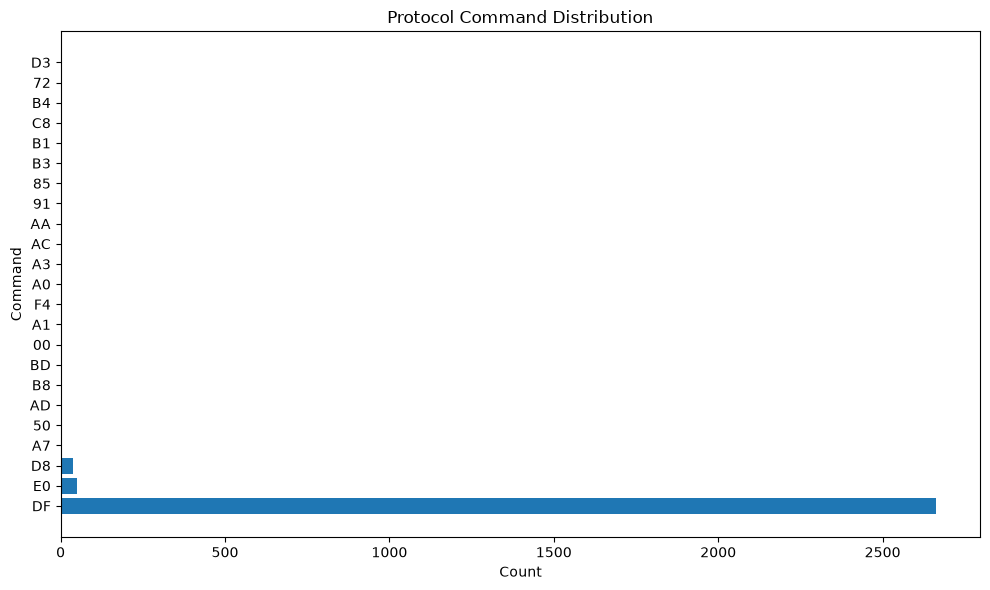

In [14]:

plt.figure(figsize=(10, 6))

plt.barh(
    command_counts["command"],
    command_counts["count"]
)

plt.xlabel("Count")
plt.ylabel("Command")
plt.title("Protocol Command Distribution")

plt.tight_layout()
plt.show()



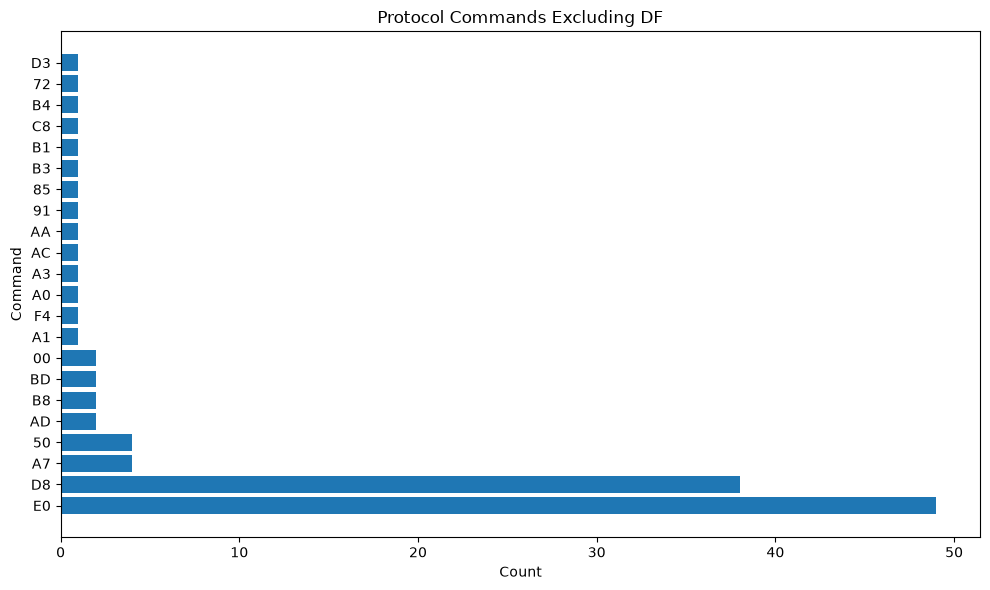

In [15]:
non_df = command_counts[command_counts["command"] != "DF"].copy()

plt.figure(figsize=(10, 6))

plt.barh(
    non_df["command"],
    non_df["count"]
)

plt.xlabel("Count")
plt.ylabel("Command")
plt.title("Protocol Commands Excluding DF")

plt.tight_layout()
plt.show()







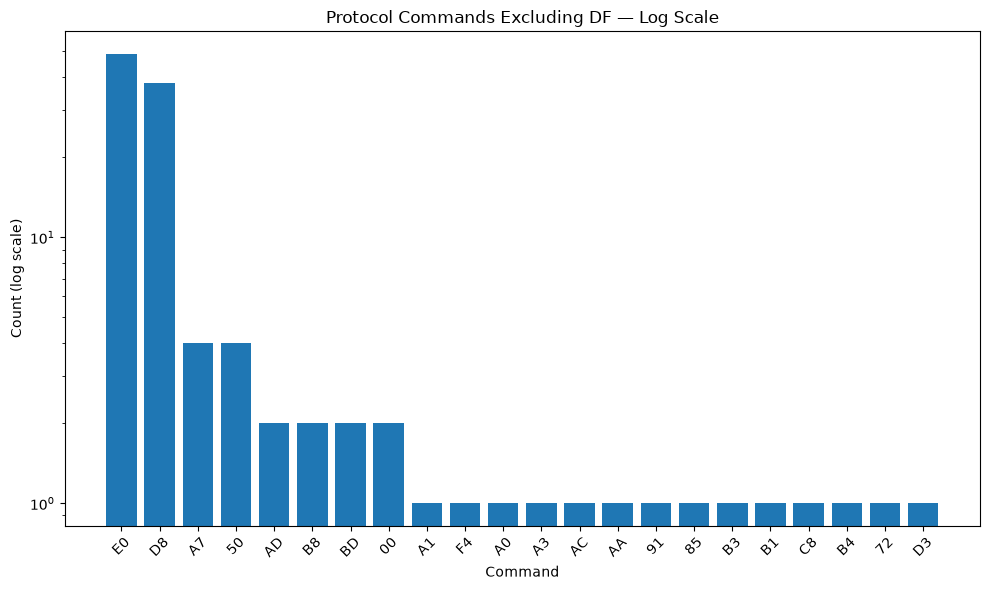

In [16]:
non_df = command_counts[command_counts["command"] != "DF"].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    non_df["command"],
    non_df["count"]
)

plt.yscale("log")

plt.xlabel("Command")
plt.ylabel("Count (log scale)")
plt.title("Protocol Commands Excluding DF — Log Scale")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
